In [ ]:
DATA_DIR = "make-it-a-habit_set-a-clean-file-system/nilearn_data"
RANDOM_STATE = 42

### My (personal) workflow:
- `%matplotlib inline` is a "magic command" for Jupyter/IPython environments, not normal Python syntax.
- Put most of your imports in the top level cell because that makes module dependencies easier to see. Tutorial imports are so scattered...
  > You only need one import for each module or each function from a module, not an import in every cell.
- <strong>Please always print variable types and data shapes when you are unsure instead of diving directly into analysis or visualization.</strong>

In [27]:
# %matplotlib inline 
from IPython.display import clear_output # I'm emphasizing that i'm only importing this to make displays less ugly in Jupyter
import warnings
import re
import os
import numpy as np
import pandas as pd
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     PredefinedSplit,
                                     RepeatedKFold,
                                     RepeatedStratifiedKFold,
                                     KFold,
                                     LeaveOneOut,
                                     StratifiedKFold,
                                     BaseCrossValidator,
                                     cross_val_predict,
                                     cross_val_score,
                                     cross_validate,
                                     validation_curve)
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_regression
from sklearn.svm import SVR, LinearSVR, SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt
import nilearn
from nilearn import datasets, plotting, image
from nilearn.connectome import ConnectivityMeasure

In [ ]:
data = datasets.fetch_development_fmri(data_dir=DATA_DIR, verbose=0, resume=True)
clear_output()

# Please always print variable types and data shapes
print(f">> type of `data` = {type(data)}\n\n>> attributes:")
for i, attr in enumerate(dir(data)):
    print(f"    {i+1}. {attr}\n    `type(data.{attr})` = {type(data[attr])}\n    {data[attr]}\n")

In [5]:
subj_desc = '''The dataset consists of 50 children (ages 3-13) and 33 young adults (ages
18-39). This dataset can be used to try to predict who are adults and
who are children.'''
print(f"Dataset description says:\n'{subj_desc}'\n")
print(f">> No idea why `data.func` gives {len(data.func)} subjects???")

Dataset description says:
'The dataset consists of 50 children (ages 3-13) and 33 young adults (ages
18-39). This dataset can be used to try to predict who are adults and
who are children.'

>> No idea why `data.func` gives 155 subjects???


In [182]:
pheno = data.phenotypic
display(pheno)
print(f">> Number of samples = {len(pheno)}")
print(f">> Number of individual subjects = {len(pheno['participant_id'].unique())}")
print(f">> Number of children = {len(pheno.loc[pheno['Child_Adult']=='child'])}") 
print(f">> Number of adults = {len(pheno.loc[pheno['Child_Adult']=='adult'])}")

# save it to excel so you can load it back later
pheno.to_excel(f"{DATA_DIR}/pheno.xlsx", index=False)

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness
154,sub-pixar155,26.00,Adult,adult,M,R
122,sub-pixar123,27.06,Adult,adult,F,R
123,sub-pixar124,33.44,Adult,adult,M,R
124,sub-pixar125,31.00,Adult,adult,M,R
125,sub-pixar126,19.00,Adult,adult,F,R
...,...,...,...,...,...,...
53,sub-pixar054,5.99,5yo,child,M,R
54,sub-pixar055,5.82,5yo,child,M,L
55,sub-pixar056,5.26,5yo,child,F,R
48,sub-pixar049,5.23,5yo,child,M,R


>> Number of samples = 155
>> Number of individual subjects = 155
>> Number of children = 122
>> Number of adults = 33


Please also try to read the official function <strong>documenations</strong>. Try changing the arguments and see what happens. Oftentimes, tutorials only use default values, which means most arguments will not be passed.
- [nilearn.datasets.fetch_atlas_basc_multiscale_2015](https://nilearn.github.io/dev/modules/generated/nilearn.datasets.fetch_atlas_basc_multiscale_2015.html)
- [nilearn.plotting](https://nilearn.github.io/dev/modules/plotting.html)
- [nilearn.masker.NiftiMasker](https://nilearn.github.io/dev/modules/generated/nilearn.maskers.NiftiMasker.html)

Atlas ROIs are located in nifti image (4D) at:
/nilearn_data/basc_multiscale_2015/template_cambridge_basc_multiscale_nii_sym/template_cambridge_basc_multiscale_sym_scale064.nii.gz




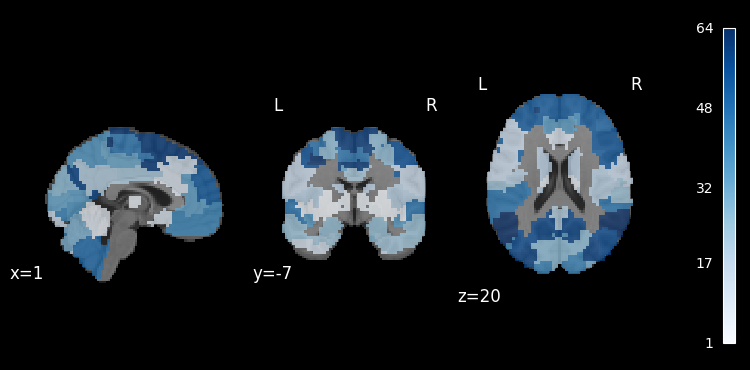

In [183]:
parcellations = datasets.fetch_atlas_basc_multiscale_2015(data_dir=DATA_DIR, resolution=64, version="sym")
atlas_filename = parcellations.maps

clear_output()

print(f"Atlas ROIs are located in nifti image (4D) at:\n{'/nilearn' + atlas_filename.split('nilearn')[-1]}\n\n")
_ = plotting.plot_roi(atlas_filename,
                  display_mode="ortho",
                  cut_coords=(1, -7, 20),
                  black_bg=True,
                  cmap="Blues",
                  cbar_tick_format="%.2g",
                  dim=1.5,
                  resampling_interpolation="continuous",
                  draw_cross=False)

File path to to the first subject:
/nilearn_data/development_fmri/development_fmri/sub-pixar155_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz



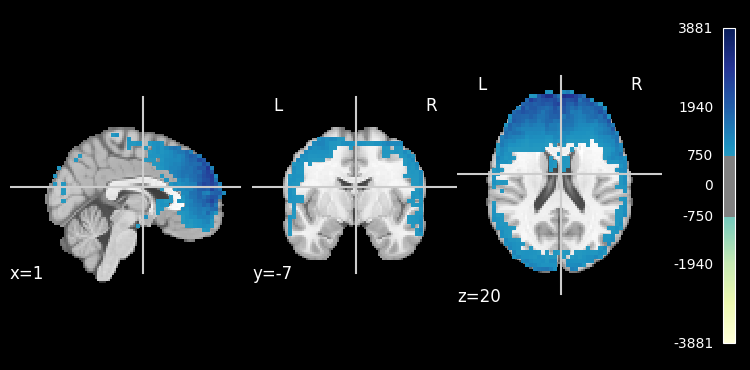

In [184]:
# grab 1st subject
fmri_filename = data.func[0]
print(f"File path to to the first subject:\n{'/nilearn' + fmri_filename.split('nilearn')[-1]}\n")

# average over time (4D to 3D)
averaged_Img = image.mean_img(fmri_filename)
_ = plotting.plot_stat_map(averaged_Img,
                       display_mode="ortho",
                       cut_coords=(1, -7, 20),
                       black_bg=True,
                       threshold=750,
                       cmap="YlGnBu",
                       cbar_tick_format="%i",
                       dim=-0.15,
                       resampling_interpolation="nearest",
                       draw_cross=True)

The `nilearn.input_data.NiftiLabelMasker` import and passing `standardize=True` have version breaks (FutureWarning). Handling it with warning filters and try-except blocks (to make it print the warnings for demonstration; in general you just don't use the deprecated version).

In [185]:
warnings.filterwarnings("error", category=FutureWarning)
warning1, warning2 = None, None

try:
    from nilearn.input_data import NiftiLabelsMasker # deprecated in version 0.9
except FutureWarning:
    warning1 = """**FutureWarning**: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker\n"""
    from nilearn.maskers import NiftiLabelsMasker

# Confounds to be regressed out during signal extraction
conf = data.confounds[0]
print(f"Confound for the first subject:\n{conf}\n\n")

try:
    masker = NiftiLabelsMasker(labels_img=atlas_filename, 
                               standardize=True, 
                               memory="nilearn_cache", 
                               verbose=11)
    time_series = masker.fit_transform(fmri_filename, confounds=conf)
    clear_output()
except FutureWarning:
    warning2 = """**FutureWarning**: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(fmri_filename, confounds=conf)\n"""
    masker = NiftiLabelsMasker(labels_img=atlas_filename, 
                               standardize="zscore_sample", # <- change standardize=True to standardize="zscore_sample"
                               memory="nilearn_cache", 
                               verbose=1)
    time_series = masker.fit_transform(fmri_filename, confounds=conf)

time_series = masker.fit_transform(fmri_filename, confounds=conf)
clear_output()

print(f"{warning1}\n{warning2}\n")
print(f">> type of `time_series` = {type(time_series)}")
if type(time_series) == np.ndarray:
    print(f">> shape of `time_series` = {time_series.shape}")

**FutureWarning**: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker

**FutureWarning**: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(fmri_filename, confounds=conf)


>> type of `time_series` = <class 'numpy.ndarray'>
>> shape of `time_series` = (168, 64)


In [186]:
conf_df = pd.read_csv(conf,sep="\t")
display(conf_df.head())
print(f"...\n\n{conf_df.shape[0]} rows x {conf_df.shape[1]} columns") # axis 0 : time

,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,framewise_displacement,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,a_comp_cor_04,a_comp_cor_05,csf,white_matter
0,0.000026,0.016408,-0.056215,0.000558,0.000285,5.293960e-23,0.000000,-0.046390,0.038942,-0.088607,0.075298,-0.030558,0.031768,529.770780,564.239912
1,0.000019,-0.012647,-0.087373,0.001007,0.000161,0.000000e+00,0.088935,0.048373,0.031197,0.009106,-0.061769,-0.126338,0.059055,527.719045,563.270479
2,0.008983,0.065654,-0.033006,0.000317,0.000165,0.000000e+00,0.176392,-0.088955,-0.005404,-0.011809,0.001806,-0.026253,-0.077592,528.488882,564.703652
3,0.011467,-0.009904,0.022973,-0.001038,-0.000000,4.666510e-04,0.233372,-0.121047,0.075566,0.049781,0.054006,-0.043817,-0.034061,529.259402,565.082273
4,-0.013230,0.087269,-0.023619,-0.000658,-0.000000,-1.589520e-04,0.218749,-0.095217,-0.089078,-0.051393,0.061453,-0.162568,-0.073265,532.574817,565.350249


...

168 rows x 15 columns


Another FutureWarning about standardization...

In [187]:
warning3 = None

try:
    corr_measure = ConnectivityMeasure(kind="correlation")
    outputs = corr_measure.fit_transform([time_series]) # shape = (n_subjects, n_features, n_features)
except FutureWarning:
    warning3 = """**FutureWarning**: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead."""
    corr_measure = ConnectivityMeasure(kind="correlation", standardize="zscore_sample")
    outputs = corr_measure.fit_transform([time_series]) # shape = (n_subjects, n_features, n_features)
    clear_output()

print(f"{warning3}\n")
print(f"fit_transform output shape = {outputs.shape}")
corr_matrix = outputs[0]
print(f"Correlation matrix shape = {corr_matrix.shape}; n_features = {corr_matrix.shape[0]}") # we only have one subject right now

**FutureWarning**: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.

fit_transform output shape = (1, 64, 64)
Correlation matrix shape = (64, 64); n_features = 64


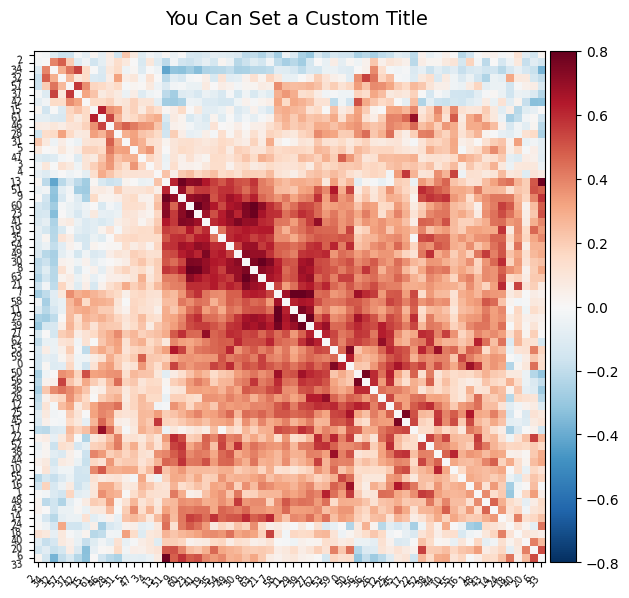

In [42]:
# plot the correlation matrix
# Mask the main diagonal for visualization:
np.fill_diagonal(corr_matrix, 0)

# The labels we have start with the background (0), hence we skip the first label
fig, axes = plt.subplots(1, 1, figsize=(7, 7))
fig.suptitle("You Can Set a Custom Title", y=0.92, fontsize=14)
_ = plotting.plot_matrix(corr_matrix, 
                     labels=range(time_series.shape[-1]),
                     vmax=0.8, vmin=-0.8,
                     auto_fit=True,
                     reorder="complete",
                     axes=axes)


# matrices are ordered for block-like representation

> I've tried adjusting fig and ax parameters to make that correlation matrix plot less ugly... but to no avail... ><

### They introduced for loops, so let's take it up a notch :D
- Explicit for loops
- While loops
- List/dict comprehensions
- Iterators
- Generators

Python for loops over iterables like `range()` are often faster than equivalent while loops, because the iteration is handled by optimized C-level iterator machinery, whereas while loops rely on repeated Python-level condition checks and iterative updates

In [305]:
from time import perf_counter

N = 1000000

start1 = perf_counter()
for i in range(N):  # optimized C-level iterator loop
    pass
end1 = perf_counter()
print(f"i = {i} after for loop ends")

i = 0
start2 = perf_counter()
while i < N:  # Python-level loop with repeated condition checks + increments
    i += 1
end2 = perf_counter()
print(f"i = {i} after while loop ends")

print(f"  >> for loop took {end1 - start1:.4f} secs")
print(f"  >> while loop took {end2 - start2:.4f} secs")

i = 999999 after for loop ends
i = 1000000 after while loop ends
  >> for loop took 0.0167 secs
  >> while loop took 0.0427 secs


However, this does not mean while loops are useless or should be avoided just because they're not C-optimized! There <i>are</i> cases where a while loop is more appropriate, like when you do not know in advance when the loop will terminate (a for loop needs an iterable, which defines a sequence to iterate through) and the stopping criterion emerges dynamically. E.g., <i>binary search.</i>

In [327]:
def binary_search(seq, target):
    if sorted(seq) != sorted(seq):
        raise ValueError("List must be sorted!")
    left, right = 0, len(seq) - 1
    while True:
        mid = (left + right)//2 
        if left > right:
            print(f"Target {target} not in seuqnce!")
            return None
        if target == seq[mid]:
            print(f"Target {target} at index {mid}")
            return mid
        elif target < seq[mid]:
            right = mid - 1
        else:
            left = mid + 1

seq = [2,5,8,16,23,38,56,72,91,101,105,566,721,777,999]
idx = binary_search(seq, 105)
_ = binary_search(seq, 7)

Target 105 at index 10
Target 7 not in seuqnce!


<strong>List and dictionary comprehensions</strong> are often faster and more concise than equivalent explicit for loops because they are executed in a more optimized internal evaluation path in CPython, with less Python-level overhead per iteration. However, the main reason to use them is readability and expressiveness, not necessarily performance. Below is an example where I grab all the .nii.gz files with resolution >= 64.

In [ ]:
import re

sub_dir = "basc_multiscale_2015/template_cambridge_basc_multiscale_nii_sym"
def check_resolution(file):
    matched = re.findall(r"[0-9]+", file)
    if not matched:
        return -1
    else:
        return int(matched[0])


# explicit for loop with .append()
lst1 = []
for file in os.listdir(f"{DATA_DIR}/{sub_dir}"):
    if check_resolution(file) >= 64:
        lst1.append(file)


# list comprehension
lst2 = [file for file in os.listdir(f"{DATA_DIR}/{sub_dir}") if check_resolution(file) >= 64]

assert lst1 == lst2 # sanity checking that those two lists are equivalent
display(lst2)

# dict comprehenstion
dict2 = {check_resolution(file): file for file in os.listdir(f"{DATA_DIR}/{sub_dir}") if check_resolution(file) >= 64}
display(dict2)

['template_cambridge_basc_multiscale_sym_scale064.nii.gz',
 'template_cambridge_basc_multiscale_sym_scale197.nii.gz',
 'template_cambridge_basc_multiscale_sym_scale444.nii.gz',
 'template_cambridge_basc_multiscale_sym_scale122.nii.gz',
 'template_cambridge_basc_multiscale_sym_scale325.nii.gz']

{64: 'template_cambridge_basc_multiscale_sym_scale064.nii.gz',
 197: 'template_cambridge_basc_multiscale_sym_scale197.nii.gz',
 444: 'template_cambridge_basc_multiscale_sym_scale444.nii.gz',
 122: 'template_cambridge_basc_multiscale_sym_scale122.nii.gz',
 325: 'template_cambridge_basc_multiscale_sym_scale325.nii.gz'}

$\text{Generator} \subset \text{Iterator} \subset \text{Iterable}$

In [331]:
from collections.abc import Iterable, Iterator
from types import GeneratorType

lst = [1,1,2,3,5,8]
print(f"type(lst) = {type(lst)}")
print(f"lst is an iterable: {isinstance(lst, Iterable)}")
print(f"lst is an iterator: {isinstance(lst, Iterator)}")
print(f"lst is a generator: {isinstance(lst, GeneratorType)}")
print(f"lst has methods __iter__: {hasattr(lst, '__iter__')}")
print(f"lst has methods __next__: {hasattr(lst, '__next__')}\n")

lst_iterator = iter(lst)
print(f"type(lst_interator) = {type(lst_iterator)}")
print(f"lst_iterator is an iterable: {isinstance(lst_iterator, Iterable)}")
print(f"lst_iterator is an iterator: {isinstance(lst_iterator, Iterator)}")
print(f"lst_iterator is a generator: {isinstance(lst_iterator, GeneratorType)}")
print(f"lst_iterator has methods __iter__: {hasattr(lst_iterator, '__iter__')}")
print(f"lst_iterator has methods __next__: {hasattr(lst_iterator, '__next__')}\n")

while True:
    try:
        print(next(lst_iterator))
    except StopIteration:
        print(">> StopIteration")
        break

type(lst) = <class 'list'>
lst is an iterable: True
lst is an iterator: False
lst is a generator: False
lst has methods __iter__: True
lst has methods __next__: False

type(lst_interator) = <class 'list_iterator'>
lst_iterator is an iterable: True
lst_iterator is an iterator: True
lst_iterator is a generator: False
lst_iterator has methods __iter__: True
lst_iterator has methods __next__: True

1
1
2
3
5
8
>> StopIteration


In [ ]:
import time # this is for better display used in conjunction with clear_ouput ^^

def prime_num_generator(upper_bound: int=100):
    yield 2
    for num in range(3, upper_bound+1, 2):
        check = True
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                check = False
                break
        if check:
            yield num

png1, png2 = prime_num_generator(100), prime_num_generator(100)
print(f"type(png) = {type(png1)}")
time.sleep(2)
clear_output()

while True:
    try:
        print(next(png1))
        clear_output(wait=True)
        time.sleep(0.5)
    except StopIteration:
        break
time.sleep(0.5)
clear_output(wait=True)
print(f">> Prime Numbers in [1, 100]: {[num for num in png2]}")

>> Prime Numbers in [1, 100]: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


I mentioned generators because when you're doing CV (cross-validation) using sklearn objects like `KFold`, the class method `KFold.split()` creates a <strong>generator object</strong>, not an array, not a regular list. Speciffically, in the [sklearn doc](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html):

> <strong>Yields</strong><br>
train: ndarray<br>
$\:\:$ <i>The training set indices for that split.</i><br>
test: ndarray<br>
$\:\:$ <i>The testing set indices for that split.</i><br>

So... not everything you can loop over in Python is a list.

In [355]:
X_random, y_random = np.random.randint(155, 2016), np.random.randint(155)
kf = KFold()
split = kf.split(X_random, y_random)
print(f"KFold.split() has methods __iter__: {hasattr(split, '__iter__')}")
print(f"KFold.split() has methods __next__: {hasattr(split, '__next__')}")
print(f"KFold.split() is an iterable: {isinstance(split, Iterable)}")
print(f"KFold.split() is an iterator: {isinstance(split, Iterator)}")
print(f"KFold.split() is a generator: {isinstance(split, GeneratorType)}")

KFold.split() has methods __iter__: True
KFold.split() has methods __next__: True
KFold.split() is an iterable: True
KFold.split() is an iterator: True
KFold.split() is a generator: True


Now we download all subjects' data. If you want a prettier UI, <i>maybe</i> do somthing like this this (will be about 10 ro 20-ish seconds slower though due to function call overhead). However, even without the `clear_output()` and `time.sleep()`, for some reasom using a list comprehension + feeding the entire list to `ConnectivityMeasure.fit_transform()` isn't faster than an explicit for loop...

In [17]:
from nilearn.maskers import NiftiLabelsMasker
from sklearn.utils import Bunch
import time
from time import perf_counter
warnings.filterwarnings("ignore", category=DeprecationWarning)

data = datasets.fetch_development_fmri(data_dir=DATA_DIR, verbose=0, resume=True)
parcellations = datasets.fetch_atlas_basc_multiscale_2015(data_dir=DATA_DIR, resolution=64, version="sym")
atlas_filename = parcellations.maps
corr_measure = ConnectivityMeasure(kind="correlation",
                                   standardize="zscore_sample",
                                   vectorize=True,
                                   discard_diagonal=True) # set to vectorize and drop diagonal
masker = NiftiLabelsMasker(labels_img=atlas_filename, 
                               standardize="zscore_sample", 
                               memory="nilearn_cache", 
                               verbose=0)

clear_output()

In [20]:
TOTAL_NUMB_OF_SUBJS = len(data.phenotypic)

def masker_fit_transform(idx, subj, data: Bunch, masker: NiftiLabelsMasker):
    """masker.fit_transform() and then prints"""
    ts = masker.fit_transform(subj, confounds=data.confounds[idx])
    print(f"\n>> {round((idx/TOTAL_NUMB_OF_SUBJS)*100, 2)}% of subjs")
    clear_output(wait=True)
    time.sleep(1e-8)
    return ts

START =  perf_counter()                          
ts_list = [masker_fit_transform(idx, subj, data, masker)
                        for idx, subj in enumerate(data.func)]
corr_vecs = corr_measure.fit_transform(ts_list)
END = perf_counter()

DELTA = END - START
MIN, SEC = int((DELTA % 3600) // 60), DELTA % 60

n_times, n_features = ts_list[0].shape
n_subjs, dim = corr_vecs.shape
assert (n_features * (n_features - 1)) / 2 == dim 

print(f"Took {MIN}m {SEC:.2f}s to get {n_subjs} correlation matrices of shape ({n_features}, {n_features}) stored as {dim}-dim 1D arrays.")
warnings.resetwarnings()

Took 0m 55.40s to get 155 correlation matrices of shape (64, 64) stored as 2016-dim 1D arrays.


> Their original loop with `list.append()` is faster though.<br>

```
all_features = []

#i means the number of subject and sub means the file of the subject
for i,sub in enumerate(data.func):
    time_series = masker.fit_transform(sub, confounds=data.confounds[i])
    correlation_matrix = corr_measure.fit_transform([time_series])[0]
    all_features.append(correlation_matrix)
    print('finished %s of %s'%(i+1,len(data.func)))
````

In [21]:
np.savez_compressed(f"{DATA_DIR}/MAIN_BASC064_subsamp_features", a=corr_vecs)
os.listdir(DATA_DIR)

['pheno.xlsx',
 'basc_multiscale_2015',
 'MAIN_BASC007_subsamp_features.npz',
 'README.md',
 'development_fmri',
 'MAIN_BASC064_subsamp_features.npz']

Reload load <i>both</i> the data matrix and the phenotypic data frame which we saved earlier as an XLSX file, so you don't have to re-run everything again.

In [14]:
feat_file = f"{DATA_DIR}/MAIN_BASC064_subsamp_features.npz"
pheno_file = f"{DATA_DIR}/pheno.xlsx"
try:
    X_features = np.load(feat_file)["a"]
    pheno = pd.read_excel(pheno_file)
    y_age = pheno["Age"]
except FileNotFoundError as e:
    print(e)
else:
    print(f"Feature matrix shape (n_subjs, feature_space_dim) = {X_features.shape}")
    display(pheno)

Feature matrix shape (n_subjs, feature_space_dim) = (155, 2016)


,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness
0,sub-pixar155,26.00,Adult,adult,M,R
1,sub-pixar123,27.06,Adult,adult,F,R
2,sub-pixar124,33.44,Adult,adult,M,R
3,sub-pixar125,31.00,Adult,adult,M,R
4,sub-pixar126,19.00,Adult,adult,F,R
...,...,...,...,...,...,...
150,sub-pixar054,5.99,5yo,child,M,R
151,sub-pixar055,5.82,5yo,child,M,L
152,sub-pixar056,5.26,5yo,child,F,R
153,sub-pixar049,5.23,5yo,child,M,R


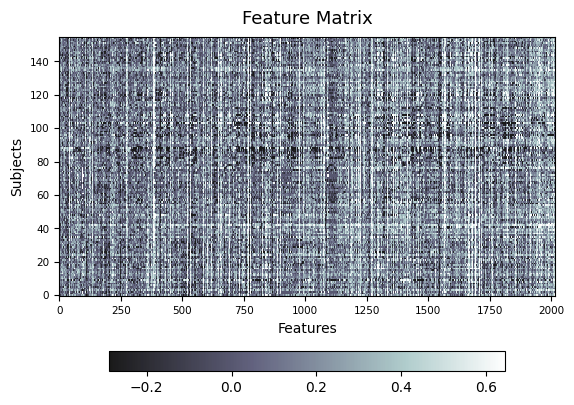

In [235]:
# visulize the feature matrix
vmin, vmax = np.quantile(X_features, 0.025), np.quantile(X_features, 0.975)
plt.pcolormesh(X_features,
               vmin=vmin, vmax=vmax,
               alpha=0.9,
               shading="nearest",
               cmap="bone")
plt.colorbar(spacing="proportional", location="bottom", shrink=0.8)
plt.title("Feature Matrix", fontsize=13, y=1.02)
plt.xlabel("Features", fontsize=10)
plt.ylabel("Subjects", fontsize=10)
plt.tick_params(axis="both", which="major", labelsize=7.5)
plt.show()

Plot the age distribition. <strong>Note that age group is for stratification</strong> (when the model is SVR, a regression model). Our target is <i>age</i>.
> `sns.distplot()` is deprecated...

In [29]:
print(pheno["AgeGroup"].value_counts())

AgeGroup
8-12yo    34
5yo       34
Adult     33
7yo       23
3yo       17
4yo       14
Name: count, dtype: int64


**UserWarning**: `distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).



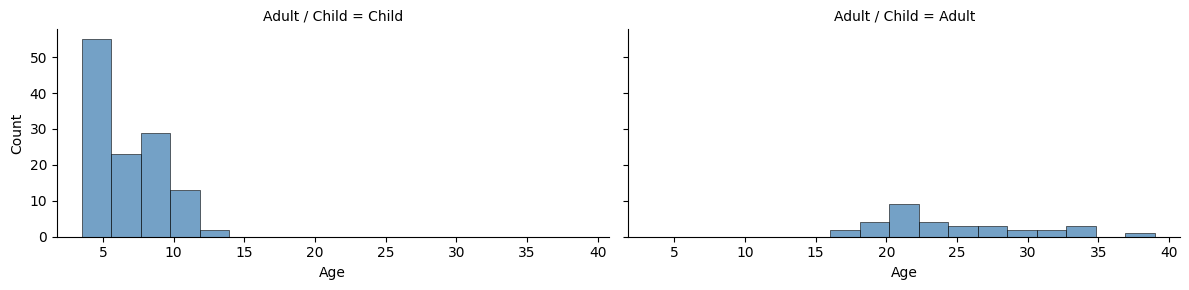

In [ ]:
warnings.filterwarnings("error", category=UserWarning)
warning4 = None

#pheno = pandas.DataFrame(data.phenotypic) # <- data.phenotypic is already a pandas data frame
#pheno.head() 

adult_child = [i if i == "Adult" else "Child" for i in pheno["AgeGroup"]]
pheno_ = pheno.copy()
pheno_.insert(list(pheno_.columns).index("AgeGroup"), "Adult / Child", adult_child)

try:
    sns.distplot(y_age)
except UserWarning:
    warning4 = """**UserWarning**: `distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).\n"""
    print(warning4)
    
    
    sns.displot(data=pheno_.loc[::-1], x="Age", col="Adult / Child",
                kind="hist", height=3, aspect=2,
                color="steelblue", linewidth=0.4, edgecolor="black")

<strong>Well, I don't think an `sns.displot()` and `sns.histplot()` after every `train_test_split()` is necessary though...</strong><br>

Yes, the age distribution is right-skewed, which is why you are stratifying by `"AgeGroup"`. But you can trust that sklearn stratification is doing its job; no need to manually inspect it after every single split unless your dataset is truly absurdly imbalanced (not the case here). Too many plots $\rightarrow$ code workflow disruption.
> Note again that you are still performing <strong>regression</strong>; stratification doesn't make it classification.

### This part is BrainHack's original code.
#### Very important note:
<strong>Accuracy and R^2 are NOT the same thing</strong>. They are different evaluation metrics for different task types. Accuracy is typically a classification metric, whereas R^2 is for regression. You can absolutely get a negative R^2 (yes, despite that "squared" in the name), but you can NEVER get a negative accuracy.

In [30]:
# split the sample to training and validation set
# but it's not a good split, see that later
age_class = pheno['AgeGroup']
X_train, X_val, y_train, y_val = train_test_split(
    X_features, y_age, test_size = 0.4, shuffle = True,  stratify = age_class,  random_state = 123)

print('training:', len(X_train), 'testing:', len(X_val))

# define the model as a linear one
# fit it to my dataset

l_svr = SVR(kernel='linear')
l_svr.fit(X_train, y_train)

# take a look at the r-square
y_pred = l_svr.predict(X_train)
acc = l_svr.score(X_train, y_train)

print('accuracy (R2)', acc) # R^2 and acuracy are NOT interchangeable

training: 93 testing: 62
accuracy (R2) 0.9998495517004914


#### Another very important note:
When you call `estimator.fit(X_train, y_train)` then `estimator.score(X_train, y_train)`, you are scoring on the dataset the model was trained on. This is NOT evaluation in the model performance sense.

> I'm not sure why they created `X_valid`, `y_valid` and then never used it... this `train/train2/test` split is not exactly a training, validation, test workflow...

> `sklearn.svm.SVR` does not have warm start, meaning every time you call `SVR.fit()`, it will [overwrite all previously fitted coefficients](https://scikit-learn.org/1.3/tutorial/basic/tutorial.html) (like it fits a fresh new model). It's not necessary to re-instantiate the model again using the class constructor.

In [32]:
# split the dataset into training, validation and test set
from sklearn.metrics import mean_absolute_error
age_class2 = pheno.loc[y_train.index,'AgeGroup']

X_train2, X_test, y_train2, y_test = train_test_split(
     X_train,  y_train, test_size = 0.25, shuffle = True, stratify = age_class2, random_state = 123)

print('training:', len(X_train2), 'testing:', len(X_test))

# train the model again
l_svr.fit(X_train2,y_train2)
y_pred = l_svr.predict(X_test)

acc = l_svr.score(X_test, y_test)
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)

print('accuracy (R2) = ', acc)  # R^2, not accuracy
print('MAE = ',mae)

training: 69 testing: 24
accuracy (R2) =  0.6988062901513172
MAE =  3.285369344329286


### To the best of my knowledge... I am confused by the `train/val/train2` split, hmmm...
> There <strong>isn't</strong> necessarily something wrong when you get a high training score. Unless you evaludate on a heldout set and see a bad validation score relative to training score, you <i>can't</i> call that overfitting -- and they never did that; `X_val` and `y_val` were created and then never used.

Here's what I would do:
- Step 1a:
    - Split data into 80% train + 20 % test.
    - Check $R^2_{train} - R^2_{test}$.
    - Then, and only then, can you suspect overfitting or not.
- Step 1b:
    - Don't split the data. 
    - Use `cross_validate()` (with multiple evalidation metrics) to get out-of-fold performances.
    - That is usually more stable than one fixed held-out test set.

> Steps 2 and 3 we do hyperparameter-tuning.
- Step 2:
    - Split data into 70% train + 15% valid + 15% test (needs `train_test_split` done twice).
    - Use the valid set for hyperparameter-tuning (a fixed held-out version; not cross-validation).
    - Pick the model with the best hyperparameters, and train again on the union of train and valid sets.
    - Score on test set, once.
- Step 3:
    - Split data into 85 % train_valid + 15% test.
    - Cross validate on train_valid for hyperparameter-tuning (use sklearn built-in functions).
    - Pick the model with the best hyperparameters, and train again on train_valid.
    - Score on test set, once.

### Step 1a

In [501]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y_age,
                                                test_size=0.2,
                                                shuffle=True,
                                                stratify=pheno["AgeGroup"],
                                                random_state=RANDOM_STATE)
print(f"train: {len(X_train)} | test: {len(X_test)}")

l_svr = SVR(kernel="linear")
l_svr.fit(X_train, y_train)

print(f"Model fit status (0 correctly fitted; 1 otherwise): {l_svr.fit_status_}")
print(f"Training matrix shape (n_sampels, feature_space_dim) = {l_svr.shape_fit_}")

r2_train = l_svr.score(X_train, y_train)
r2_test = l_svr.score(X_test, y_test)
print(f"\n  >> Training R^2 = {r2_train}\n  >> Test R^2 = {r2_test}")

train: 124 | test: 31
Model fit status (0 correctly fitted; 1 otherwise): 0
Training matrix shape (n_sampels, feature_space_dim) = (124, 2016)

  >> Training R^2 = 0.9991220618494839
  >> Test R^2 = 0.3368445000383653


$\uparrow$ <strong>Yes, only <i>then</i> do we suspect that's overfitting.</strong>

### Step 1b
You can pass `scoring=["r2", "neg_mean_absolute_error"]` to `cross_validate()`, instead of separately calling `cross_val_predict()` and `cross_avl_score()`. It's more code, yes, but indexing helps with understanding what cross validation really is doing under the hood.

In [502]:
# IMPORTANT!!!
# please pass cv=kf with shuffle=True, not cv=5
# because with cv=5, by default sklearn does NOT shuffle th data
# our dataset is ORDERED (by age, where adults are indexed lower and children higher)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_age_arr = y_age.to_numpy()
cv_results = cross_validate(
                           SVR(kernel="linear"),
                           X_features, y_age_arr,
                           scoring=["r2", "neg_mean_absolute_error"],
                           cv=kf,
                           n_jobs=-1,
                           return_train_score=True,
                           return_estimator=True,
                           return_indices=True,
                           )
train_r2, test_r2 = cv_results["train_r2"], cv_results["test_r2"]
train_neg_mae, test_neg_mae = cv_results["train_neg_mean_absolute_error"], cv_results["test_neg_mean_absolute_error"]
print(f"Train R^2: {['Fold ' + str(i+1) + ': ' + str(round(s, 3)) for i, s in enumerate(train_r2)]}")
print(f"Test R^2: {['Fold ' + str(i+1) + ': ' + str(round(s, 3)) for i, s in enumerate(test_r2)]}")
print(f"\nTrain Neg MAE: {['Fold ' + str(i+1) + ': ' + str(round(s, 3)) for i, s in enumerate(train_neg_mae)]}")
print(f"Test Neg MAE: {['Fold ' + str(i+1) + ': ' + str(round(s, 3)) for i, s in enumerate(test_neg_mae)]}")


Train R^2: ['Fold 1: 1.0', 'Fold 2: 1.0', 'Fold 3: 0.999', 'Fold 4: 1.0', 'Fold 5: 0.998']
Test R^2: ['Fold 1: 0.494', 'Fold 2: 0.588', 'Fold 3: 0.631', 'Fold 4: 0.364', 'Fold 5: 0.415']

Train Neg MAE: ['Fold 1: -0.099', 'Fold 2: -0.099', 'Fold 3: -0.114', 'Fold 4: -0.098', 'Fold 5: -0.132']
Test Neg MAE: ['Fold 1: -5.062', 'Fold 2: -3.385', 'Fold 3: -3.474', 'Fold 4: -4.055', 'Fold 5: -3.215']


If you really want to get the predictions, use the test indices and estimators for each fold.

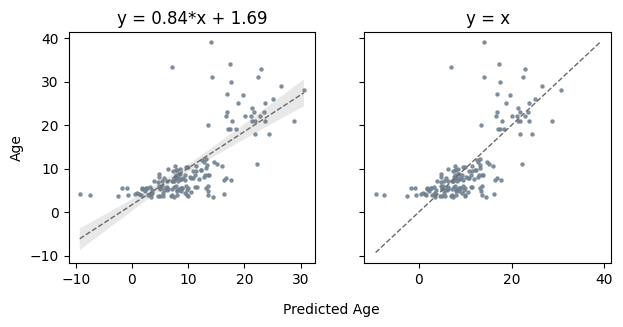

In [503]:
from scipy.stats import linregress

estimators = cv_results["estimator"]
test_indices = cv_results["indices"]["test"]

ground_truths = np.concatenate([y_age_arr[test_idx] for test_idx in test_indices])
predictions = np.concatenate([est.predict(X_features[test_idx]) for est, test_idx in zip(estimators, test_indices)])

scatter_kws = {"s": 5, "color": "slategrey"}
line_kws = {"linewidth": 1, "color": "dimgrey", "linestyle": "--"}
fig, axes = plt.subplots(1, 2, figsize=(7,3), sharey=True)
sns.regplot(x=predictions, y=ground_truths, ax=axes[0], scatter_kws=scatter_kws, line_kws=line_kws)
sns.regplot(x=predictions, y=ground_truths, ax=axes[1], scatter_kws=scatter_kws, fit_reg=False)
x = np.linspace(min(np.concatenate([predictions, ground_truths])),
                max(np.concatenate([predictions, ground_truths])),
                100)
ols_res = linregress(predictions, ground_truths)
axes[0].set_title(f"y = {round(ols_res.slope, 2)}*x + {round(ols_res.intercept, 2)}", fontsize=12)

axes[1].plot(x, x, **line_kws)
axes[1].set_title("y = x", fontsize=12)

axes[0].set_ylabel("Age", fontsize=10)
fig.supxlabel("Predicted Age", y=-0.07, fontsize=10)

plt.show()

#### Important note... again
`sns.regplot()` [plots data and a linear regression model fit](https://seaborn.pydata.org/generated/seaborn.regplot.html) by default (`fit_reg=True`, `logistic=False`, `order=1`, `logx=False`). However, what we really are comparing here is the agreement $\hat{{y_{\text{age}}}} = y_{\text{age}}$. Moreover, in the default evaluation metric, i.e.,

$R^2 = 1 - \frac{\sum_i (y_i - \hat{y_i})^2}{\sum_i (y_i - \bar{y})^2}$

the numerator is the summed squared difference between the each target value (ground truth) and the model's prediction. So the more interpretive plot would be to plot an identity line $y=x$ instead -- in which case, plain matplotlib is quite sufficient.

> PS Suppose we don't care about exact agreement in the $\hat{{y_{\text{age}}}} = y_{\text{age}}$ sense; suppose we consider the model "good enough" as long as its predicitons follow the same linear trend as the ground truths. <i>Then</i> `sns.regplot()` with a linear regression line would be informative. But again, that deson't seem to be what we're trying to visually assess right here.

### Step 2
You need to split twice.

In [ ]:
TEST_SIZE = 0.15
VALID_SIZE = 0.1765
# -> train : valid : test = 70% : 15% : 15%

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_features,
                                                    y_age,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    stratify=pheno["AgeGroup"],
                                                    random_state=RANDOM_STATE)


X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid,
                                                    y_train_valid,
                                                    test_size=VALID_SIZE,
                                                    shuffle=True,
                                                    stratify=pheno.loc[y_train_valid.index,"AgeGroup"],
                                                    random_state=RANDOM_STATE)

# sanity check
assert len(X_train) + len(X_valid) + len(X_test) == len(X_features)
print(f"train: {len(X_train)} | valid: {len(X_valid)} | test: {len(X_test)}")

train: 107 | valid: 24 | test: 24


Tune C and epsilon. You <strong>do not</strong> need to tune gamma for a linear kernel; it doesn't have gamma.
> I am manually looping here using a small grid. In standard sklearn workflow, you typically use a searcher like `GridSearchCV` combined with `PredefinedSplit`, but that's kind of beyond scope.

In [42]:
# Create hyperparameter grids for C and epsilon using a small grid 
c_grid = np.logspace(-1, 1, 5) 
epsilon_grid = np.linspace(0.01, 0.2, 5)
grid = [(c, epsilon) for c in c_grid for epsilon in epsilon_grid]

train_scores, valid_scores = [], []
for c, epsilon in grid:
    l_svr = SVR(kernel="linear", C=c, epsilon=epsilon)
    l_svr.fit(X_train, y_train)
    train_scores.append(l_svr.score(X_train, y_train))
    valid_scores.append(l_svr.score(X_valid, y_valid))
valid_scores = np.array(valid_scores)

best_idx = np.argmax(valid_scores)
print(f"Best valid R^2 = {valid_scores[best_idx]}")
best_c, best_epsilon = grid[best_idx]
print(f"Best parameter set: C={best_c}, epsilon={best_epsilon}")

l_svr = SVR(kernel="linear", C=best_c, epsilon=best_epsilon)
l_svr.fit(X_train_valid, y_train_valid)
print(f"\n  >> R^2 on tarin+valid w/ best hyperparams = {l_svr.score(X_train_valid, y_train_valid)}")
print(f"  >> R^2 on test w/ best hyperparams = {l_svr.score(X_test, y_test)}")

print(f"\nAll the train R^2's (rounded) during hyperparameter tuning, by the way:\n{[round(s, 3) for s in train_scores]}")


Best valid R^2 = 0.4432523241487093
Best parameter set: C=0.1, epsilon=0.01

  >> R^2 on tarin+valid w/ best hyperparams = 0.8161561137914751
  >> R^2 on test w/ best hyperparams = 0.5463175609834614

All the train R^2's (rounded) during hyperparameter tuning, by the way:
[0.863, 0.863, 0.863, 0.863, 0.863, 0.968, 0.969, 0.969, 0.969, 0.969, 1.0, 1.0, 1.0, 1.0, 0.999, 1.0, 1.0, 1.0, 1.0, 0.999, 1.0, 1.0, 1.0, 1.0, 0.999]


$\uparrow$ <strong>And now we've got the hallmark symptom of overfitting...</strong>

### Step 3
Hyperparameter tuning using cross validation and randomized search (usually faster than grid search).

In [46]:
# We actually already have the X_train_valid, y_train_valid split, but for the sake of demonstration, I'll split again
TEST_SIZE = 0.15
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_features,
                                                    y_age,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    stratify=pheno["AgeGroup"],
                                                    random_state=RANDOM_STATE)

c_dist = np.logspace(-3, 3, 50) # 1e-3 -> 1e3
epsilon_dist = np.linspace(0.001, 0.2, 50)

# Please name it kf, not skf; skf is usually for StratifiedKFold
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
searcher = RandomizedSearchCV(estimator=SVR(kernel="linear"),
                              cv=kf,
                              scoring=None, # this means use the estimator's (model's) default scoring, in this case R^2
                              refit=False, 
                              param_distributions={"C": c_dist,
                                                    "epsilon": epsilon_dist},
                              n_jobs=-1,
                              n_iter=200,
                              random_state=RANDOM_STATE,
                              return_train_score=True)
searcher.fit(X_train_valid, y_train_valid)

best_score, best_params = searcher.best_score_, searcher.best_params_
print(f"Best mean cross val R^2 = {best_score}")
print(f"Best hyperparameters = {best_params}")

l_svr = SVR(kernel="linear")
l_svr.set_params(**best_params)          # set the hyperparameters
l_svr.fit(X_train_valid, y_train_valid)  # fit again on train+valid
print(f"\n  >> R^2 on train+valid w/ best hyperparams = {l_svr.score(X_train_valid, y_train_valid)}")
print(f"  >> R^2 on test w/ best hyperparams = {l_svr.score(X_test, y_test)}")

Best mean cross val R^2 = 0.5285250603979784
Best hyperparameters = {'epsilon': np.float64(0.16751020408163267), 'C': np.float64(0.1206792640639329)}

  >> R^2 on train+valid w/ best hyperparams = 0.8412601316477687
  >> R^2 on test w/ best hyperparams = 0.5623445162943637


$\uparrow$ <strong>Some observations:</strong>
- Mean CV score and test score are close $\Longrightarrow$ cross-validation hyperparameter-tuning is sensible
- Final test score lower than score on train+valid $\Longrightarrow$ still some overfitting, but more stable than a single fixed heldout set in Step 2 (CV usually <i>is</i>) more stable.
> PS Score on train+valid being high is optimistic because you are scoring on the dataset the model was fit on (excatly the issue in Step 1), and also because your model hyperparameters were tuned on that same union set.

### BrainHack's original code
#### I seem to have a lot of important notes:
The purpose of cross-validation is to get a more stable estimate of out-of-sample (i.e., the held-out set) performance, not to reduce model bias (that's more of a model class/assumptions/regularization issue) compared to one single "lucky/unlucky" held-out split, and to use the data more efficiently.

In [ ]:
# using 10=fold for reducing bias <- to the best of my knowledge... not exactly
y_pred = cross_val_predict(l_svr, X_train, y_train, cv=10)

y_pred = cross_val_predict(l_svr, X_train, y_train, cv=10)

acc = cross_val_score(l_svr, X_train, y_train, cv=10)
mae = cross_val_score(l_svr, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')

for i in range(10):
    print('Fold {} -- Acc = {}, MAE = {}'.format(i, acc[i], - mae[i]))

Fold 0 -- Acc = 0.6797844072362171, MAE = 4.390331736000072
Fold 1 -- Acc = 0.42689990757540663, MAE = 4.371317090687489
Fold 2 -- Acc = 0.5694644663255006, MAE = 3.20774418160107
Fold 3 -- Acc = 0.8954612806254153, MAE = 1.6438772641423536
Fold 4 -- Acc = 0.2173203623350871, MAE = 4.744667164998446
Fold 5 -- Acc = 0.773346986632734, MAE = 2.8947439446021206
Fold 6 -- Acc = 0.33532653869455964, MAE = 2.8730781197747017
Fold 7 -- Acc = 0.29598096625347425, MAE = 4.558524810514377
Fold 8 -- Acc = 0.49971956157868636, MAE = 5.242198714335784
Fold 9 -- Acc = 0.3853092651399085, MAE = 5.640161026840864


R2: 0.5259089754949763
MAE: 3.93881450737418


Text(0.5, 0, 'Predicted Age')

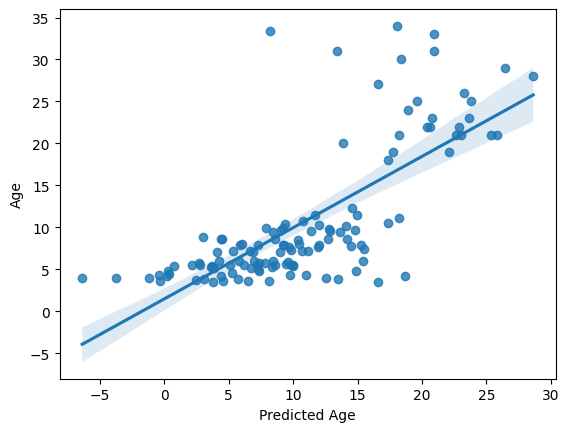

In [ ]:
# plot the results
from sklearn.metrics import r2_score

overall_acc = r2_score(y_train, y_pred)
overall_mae = mean_absolute_error(y_train,y_pred)

print('R2:',overall_acc)
print('MAE:',overall_mae)

sns.regplot(x=y_pred, y=y_train)
plt.xlabel('Predicted Age')

> Notes on `sns.regplot` later!

### Data transformation (target data, not X_features)

Actually, just `np.log(y_age)`. You don't need a `FunctionTransformer` here unless you <i>are</i> wrapping it into preprocessing steps, and in which case, you normally should not transform data that will be used as validation sets <strong>if your transformation is fit-dependent (standard scaling, for example; log transform isn't)</strong> because that causes <strong>leakage</strong>.

In [ ]:
# something like
y_log = np.log(y_age).to_numpy()
print(type(y_log))
print(y_log.shape)

<class 'numpy.ndarray'>
(155,)


Anyways, the rationale behind log-transformation is to reduce skewness.

train: 130 | test: 25


,participant_id,Age,Log,AgeGroup,Child_Adult,Gender,Handedness
154,sub-pixar155,26.00,False,Adult,adult,M,R
122,sub-pixar123,27.06,False,Adult,adult,F,R
123,sub-pixar124,33.44,False,Adult,adult,M,R


...


,participant_id,Age,Log,AgeGroup,Child_Adult,Gender,Handedness
54,sub-pixar055,3.298057,True,5yo,child,M,L
48,sub-pixar049,1.711995,True,5yo,child,M,R
77,sub-pixar078,2.509599,True,8-12yo,child,F,R


260 rows x 7 columns


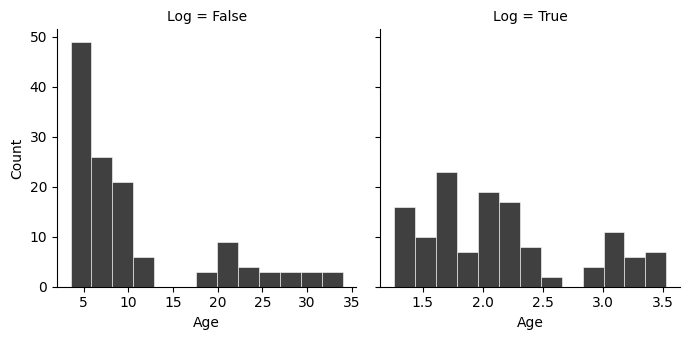

In [518]:
# using the logtransformer for the right-skewed data
# split again because our notebook is getting too long... the train test split was like 20 cells ago...
# and because I want the test set to be divisible by 10
TEST_SIZE = 0.155
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_features, y_age,
                                                test_size=TEST_SIZE,
                                                shuffle=True,
                                                stratify=pheno["AgeGroup"],
                                                random_state=RANDOM_STATE)
print(f"train: {len(X_train_valid)} | test: {len(X_test)}")

log_transformer = FunctionTransformer(func = np.log, validate=True)
log_transformer.fit(y_train.values.reshape(-1,1))
y_train_valid_log = log_transformer.transform(y_train_valid.values.reshape(-1,1))[:,0]

# create a subset of pheno, i.e., pheno_train that only contains the training set
# create another copy pheno_train_log = pheno_train.copy(), change column "Age" to log age
# vertically concatenate the two data frames
pheno_train_valid = pheno.loc[pheno["Age"].index.isin(y_train_valid.index)]
pheno_train_valid_log = pheno_train_valid.copy()
pheno_train_valid_log.insert(list(pheno.columns).index("AgeGroup"), "log_age", y_train_valid_log)
pheno_train_valid_log = pheno_train_valid_log.drop(columns=["Age"]).rename(mapper={"log_age": "Age"}, axis=1)
pheno_train_valid = pd.concat([pheno_train_valid, pheno_train_valid_log], axis=0)
pheno_train_valid.insert(list(pheno.columns).index("AgeGroup"), "Log", [False]*len(y_train_valid_log)+[True]*len(y_train_valid_log))
display(pheno_train_valid.head(3))
print("...")
display(pheno_train_valid.tail(3))
print(f"{len(pheno_train_valid)} rows x {len(pheno.columns)+1} columns")

# sns.distplot(y_train_log) <- deprecated; commenting off
g = sns.FacetGrid(pheno_train_valid, col="Log", sharex=False, height=3.5)
g.map_dataframe(sns.histplot, x="Age", bins=13, color="black", linewidth=0.4, edgecolor="white")
plt.show()

### Cross-validate on `(X_train_valid, y_train_valid_log)`
#### Yes, my important note again, taken from sklearn directly:
> [sklearn documentation about cross_val_predict](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html)<br>
Passing these predictions into an evaluation metric may not be a valid way to measure generalization performance. Results can differ from `cross_validate` and `cross_val_score` unless all tests sets have equal size and the metric decomposes over samples.

In BrainHack's original code below, the R^2 and MAE are <strong>aggregated post-hoc scores</strong> using OOF (out-of-fold) samples, which generally is NOT the same thing as averaging the CV scores across folds.
```
# predict
y_pred = cross_val_predict(l_svr, X_train, y_train_log, cv=10)

# scores
acc = r2_score(y_train_log, y_pred)
mae = mean_absolute_error(y_train_log,y_pred)

print('R2:',acc)
print('MAE:',mae)

sns.regplot(y_pred, y_train_log)
plt.xlabel('Predicted Log Age')
plt.ylabel('Log Age')
```

In [519]:
# reinitiate the model <- no need to
# l_svr = SVR(kernel='linear')
from collections import namedtuple

CVObject = namedtuple("CVObject", ["mean_valid_r2", "mean_valid_mae",
                                   "aggregated_r2", "aggregated_mae",
                                   "oof_pred"])

def check_cv_results(estimator, X_train_valid, y_train_valid, cv=None):
    y_train_valid_arr = np.array(y_train_valid)
    y_pred = cross_val_predict(estimator, X_train_valid, y_train_valid_arr, cv=cv)
    cv_results = cross_validate(
                           estimator,
                           X_train_valid, y_train_valid_arr,
                           scoring=["r2", "neg_mean_absolute_error"],
                           cv=cv,
                           n_jobs=None, # if n_jobs=-1, this will throw some kind of sklearn Parallel warning...
                           return_estimator=True,
                           return_indices=True,
                           )

    estimators = cv_results["estimator"]
    test_indices = cv_results["indices"]["test"]
    predictions = np.concatenate([est.predict(X_train_valid[test_idx])
                                  for est, test_idx in zip(estimators, test_indices)])
    test_indices = np.concatenate(test_indices)
    to_sort = [(p, i) for p, i in zip(predictions, test_indices)] # need to sort by index since predictions from cross_val_predict
                                                                  # are sorted by index
    predictions = np.array(sorted(to_sort, key=lambda x: x[1])).T[0]
    print(f"Sanity checking that cross_val_predict and cross_validate give the same predictions: {np.array_equal(y_pred, predictions)}")

    # now we compare the OOF test scores
    valid_r2, valid_mae = cv_results["test_r2"], - cv_results["test_neg_mean_absolute_error"]
    mean_valid_r2, mean_valid_mae = valid_r2.mean(), valid_mae.mean()

    aggregated_r2 = r2_score(y_train_valid_arr, y_pred)
    aggregated_mae = mean_absolute_error(y_train_valid_arr, y_pred)
    
    cv_obj = CVObject(mean_valid_r2, mean_valid_mae, aggregated_r2, aggregated_mae, y_pred)
    return cv_obj

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
# y_pred = cross_val_predict(l_svr, X_train, y_train_valid_log, cv=10) <- passing int cv doesn't shuffle
                                                                        # may be fine since the train_test_split already shuffled
                                                                        # but in general, better pass KFold with shuffle=True
cv_obj1 = check_cv_results(l_svr, X_train_valid, y_train_valid_log, cv=kf)
print("\nWhen each fold is of equal size (since train size 130 is divisible by 10)")
print(f" >> From cross_val_pred:\n     aggregated R^2 = {cv_obj1.aggregated_r2}\n     aggregated MAE = {cv_obj1.aggregated_mae}")
print(f" >> From cross_validate:\n     mean fold-wise OOF R^2 = {cv_obj1.mean_valid_r2}\n     mean fold-wise OOF MAE = {cv_obj1.mean_valid_mae}")


Sanity checking that cross_val_predict and cross_validate give the same predictions: True

When each fold is of equal size (since train size 130 is divisible by 10)
 >> From cross_val_pred:
     aggregated R^2 = 0.6795230010171591
     aggregated MAE = 0.2703919384798124
 >> From cross_validate:
     mean fold-wise OOF R^2 = 0.6776237231327277
     mean fold-wise OOF MAE = 0.27039193847981235


If we try a different train test split such that the folds are not of equal size (e.g., 134 samples in X_train_valid), then even MAE doesn't decompose over samples, and `cross_val_predict` will differ from `cross_validate`.

In [520]:
TEST_SIZE = 0.12
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_features, y_age,
                                                test_size=TEST_SIZE,
                                                shuffle=True,
                                                stratify=pheno["AgeGroup"],
                                                random_state=RANDOM_STATE)
print(f"train: {len(X_train_valid)} | test: {len(X_test)}")
y_train_valid_log = log_transformer.transform(y_train_valid.values.reshape(-1,1))[:,0]
cv_obj2 = check_cv_results(l_svr, X_train_valid, y_train_valid_log, cv=kf)
print("\nWhen each fold is NOT of equal size (since train size 136 is NOT divisible by 10)")
print(f" >> From cross_val_pred:\n     aggregated R^2 = {cv_obj2.aggregated_r2}\n     aggregated MAE = {cv_obj2.aggregated_mae}")
print(f" >> From cross_validate:\n     mean fold-wise OOF R^2 = {cv_obj2.mean_valid_r2}\n     mean fold-wise OOF MAE = {cv_obj2.mean_valid_mae}")


train: 136 | test: 19
Sanity checking that cross_val_predict and cross_validate give the same predictions: True

When each fold is NOT of equal size (since train size 136 is NOT divisible by 10)
 >> From cross_val_pred:
     aggregated R^2 = 0.6886484023816393
     aggregated MAE = 0.26459201548244726
 >> From cross_validate:
     mean fold-wise OOF R^2 = 0.6520551574638899
     mean fold-wise OOF MAE = 0.2653951216643739


So... is it better than non log transformed y_age? Let's do the cross validation using that same function, but feed the non log transformed y instead.

In [522]:
cv_obj3 = check_cv_results(l_svr, X_train_valid, y_train_valid, cv=kf)
print("\nWhen each fold is NOT of equal size (since train size 136 is NOT divisible by 10)")
print(f" >> From cross_val_pred:\n     aggregated R^2 = {cv_obj3.aggregated_r2}\n     aggregated MAE = {cv_obj3.aggregated_mae}")
print(f" >> From cross_validate:\n     mean fold-wise OOF R^2 = {cv_obj3.mean_valid_r2}\n     mean fold-wise OOF MAE = {cv_obj3.mean_valid_mae}")

Sanity checking that cross_val_predict and cross_validate give the same predictions: True

When each fold is NOT of equal size (since train size 136 is NOT divisible by 10)
 >> From cross_val_pred:
     aggregated R^2 = 0.5218847499571444
     aggregated MAE = 3.9616314500882464
 >> From cross_validate:
     mean fold-wise OOF R^2 = 0.4942027630478371
     mean fold-wise OOF MAE = 3.965592641011527


Well... yes... but note again thet aggregated R^2 and mean fold-wise OOF R^2 are different. So there are two subtle points here (subtle, but important):
1. Using an aggregated post-hoc metric is NOT equivalent to proper cross validation, and using the aggregated score to infer that the model performance / generalization is better is NOT the best practice (according to sklearn).
2. We are in log space. Any prediction must be inverse-transformed. `FunctionTransformer` has an `inverse_transform` class method, but still... we can do that without an sklearn import and API call -- the inverse of `np.log` is just `np.exp`...

> PS `FunctionTransformer` becomes useful and necessary when wrapped inside `Pipeline` (see the cells twoards end of this notebook where I Fisher-transformed X), but it doesn't seem to be what we're doing now. So in terms of code readability, I'd think `np.log` and `np.exp` are more appropriate.

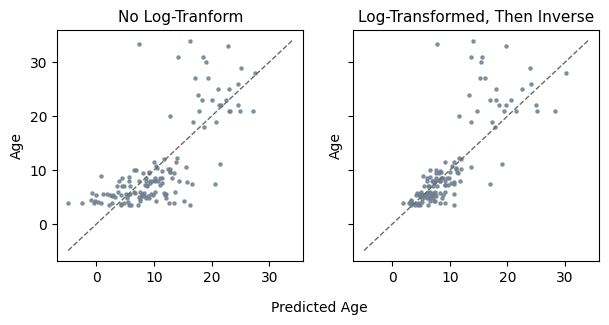

In [523]:
y_pred_log, y_pred = cv_obj2.oof_pred, cv_obj3.oof_pred
y_pred_log_exp = np.exp(y_pred_log)

scatter_kws = {"s": 5, "color": "slategrey"}
line_kws = {"linewidth": 1, "color": "dimgrey", "linestyle": "--"}
fig, axes = plt.subplots(1, 2, figsize=(7,3), sharey=True, sharex=True)

sns.regplot(x=y_pred, y=y_train_valid, ax=axes[0], scatter_kws=scatter_kws, fit_reg=False)
sns.regplot(x=y_pred_log_exp, y=y_train_valid, ax=axes[1], scatter_kws=scatter_kws, fit_reg=False)

x = np.linspace(min(np.concatenate([y_pred, y_pred_log_exp, y_train_valid])),
                max(np.concatenate([y_pred, y_pred_log_exp, y_train_valid])),
                100)

axes[0].plot(x, x, **line_kws)
axes[1].plot(x, x, **line_kws)
axes[0].set_title("No Log-Tranform", fontsize=11)
axes[1].set_title("Log-Transformed, Then Inverse", fontsize=11)

axes[0].set_ylabel("Age", fontsize=10)
fig.supxlabel("Predicted Age", y=-0.07, fontsize=10)

plt.show()

### Using `validation_curve` to visualize how validation scores change when one model hyperparameter changes (in this case, C)
Note that in the cells below our y is the original age, not log-transformed (interprataion is easier).

train_scores.shape (n_ticks, n_cv_folds) = (50, 10)
valid_scores.shape (n_ticks, n_cv_folds) = (50, 10)


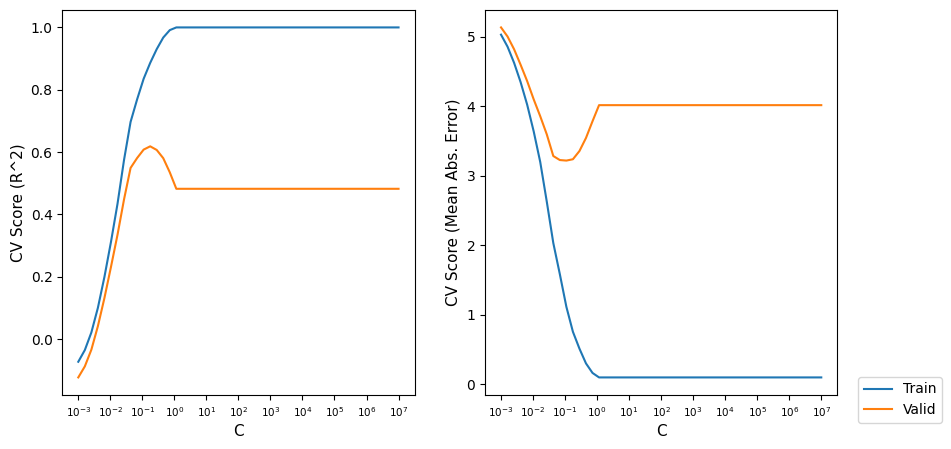

In [ ]:
from copy import deepcopy

def get_val_curve_results(estimator, X_train_valid, y_train_valid, *,
                          param_name, param_range, cv, scoring, print_stuff=False):   
    results = {param_name: param_range}
    train_scores, valid_scores = validation_curve(estimator, X_train_valid, y_train_valid,
                                                  param_name=param_name,
                                                  param_range=param_range,
                                                  scoring=scoring,
                                                  cv=cv)
    if scoring is None:
        print("Using estimaor default scoring.")
        sign = 1
    else:
        sign = -1 if "neg" in scoring else 1
    results["Train"] = sign * train_scores.mean(axis=-1)
    results["Valid"] = sign * valid_scores.mean(axis=-1)
    results["raw_train_scores"] = train_scores
    results["raw_valid_scores"] = valid_scores
    if print_stuff:
        # print(f"Scoring = {scoring}")
        print(f"train_scores.shape (n_ticks, n_cv_folds) = {train_scores.shape}")
        print(f"valid_scores.shape (n_ticks, n_cv_folds) = {valid_scores.shape}")
    return results

N_TICKS = 50
#C_range_ = 10. ** np.arange(-3, 8) # <- use np.logspace
C_range = np.logspace(-3, 7, num=N_TICKS, base=10)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=False, sharex=True)

scorings, y_labels = ["r2", "neg_mean_absolute_error"], ["CV Score (R^2)", "CV Score (Mean Abs. Error)"]
print_stuff = [True, False]
results_list = [get_val_curve_results(l_svr, X_train_valid, y_train_valid,
                                      param_name="C", param_range=C_range, cv=kf, scoring=scoring, print_stuff=boo)
                                      for scoring, boo in zip(scorings, print_stuff)]
results_list_format = deepcopy(results_list)
for d in results_list_format:
    d.pop("raw_train_scores")
    d.pop("raw_valid_scores")
results_list_format = [pd.DataFrame(res) for res in results_list_format]
for ax, res, y_label in zip(axes.flatten(), results_list_format, y_labels):
    res.plot(x="C", ax=ax, logx=True)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_xlabel("C", fontsize=11)
    ax.set_xticks(np.logspace(-3, 7, num=11, base=10))
    ax.tick_params(axis="x", which="major", labelsize=7.5)
axes[0].get_legend().remove()
axes[1].legend(bbox_to_anchor=(1.04, 0.065))
plt.show()

train_scores.shape (n_ticks, n_cv_folds) = (11, 10)
valid_scores.shape (n_ticks, n_cv_folds) = (11, 10)


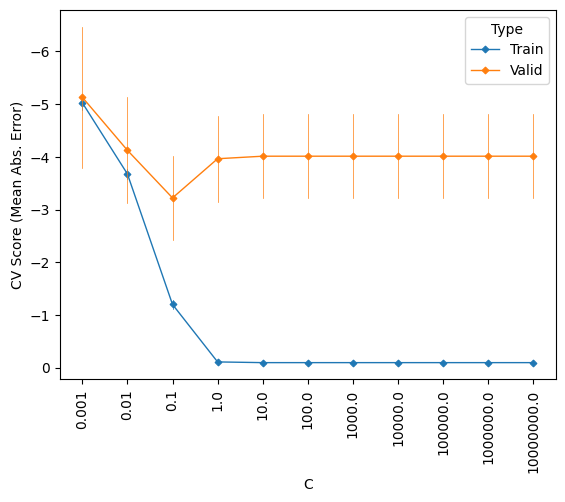

In [633]:
def format_for_point_plot(results, scoring):
    n_ticks, n_cv_folds = results["raw_train_scores"].shape
    C_range = np.tile(results["C"][:, np.newaxis], n_cv_folds)
    C_range = np.concatenate(np.unstack(C_range), axis=0)
    new_res = {"C": np.concatenate([C_range, C_range])}
    raw_train_scores = np.concatenate(np.unstack(results["raw_train_scores"], axis=0))
    raw_valid_scores = np.concatenate(np.unstack(results["raw_valid_scores"], axis=0))
    new_res[scoring] = np.concatenate([raw_train_scores, raw_valid_scores])
    new_res["Type"] = ["Train"] * len(raw_train_scores) + ["Valid"] * len(raw_valid_scores)
    new_res["Fold"] = list(range(1, n_cv_folds+1)) * (2 * n_ticks)
    return pd.DataFrame(new_res)

results_list = [get_val_curve_results(l_svr, X_train_valid, y_train_valid,
                                      param_name="C", param_range=np.logspace(-3, 7, num=11, base=10), cv=kf,
                                      scoring=scoring, print_stuff=boo)
                                      for scoring, boo in zip(scorings, print_stuff)]
dfs_for_cat = [format_for_point_plot(res, y_label) for res, y_label in zip(results_list, y_labels)]

g = sns.pointplot(x="C",y=y_labels[1],hue="Type",data=dfs_for_cat[1], errorbar=("sd", 1),
                  marker="D", markersize=3.5,
                  err_kws={"linewidth": 0.5}, linewidth=1)
plt.xticks(range(len(np.logspace(-3, 7, num=11, base=10))))
g.set_xticklabels(np.logspace(-3, 7, num=11, base=10), rotation=90)
g.invert_yaxis()
plt.show()


### Hyperparameter tuning with Fisher z-transform and feature selection (`SelectPercentile`) 
- $z = Fisher(r) = \text{arctanh}(r) = \frac{1}{2}\text{ln}(\frac{1+r}{1-r})$
- Yes, you can tune the percentile too!


In [ ]:
def fisher(X):
    eps = 1e-8
    X = np.clip(X, -1+eps, 1-eps) # avoid zero division and zero ln
    return np.arctanh(X)
fisher_transformer = FunctionTransformer(fisher)

TEST_SIZE = 0.2
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_features,
                                                    y_age,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    stratify=pheno["AgeGroup"],
                                                    random_state=RANDOM_STATE)
percentile_dist = list(range(5, 26)) # 5 % -> 25%
c_dist = np.logspace(-3, 3, 100) # 1e-3 -> 1e3
epsilon_dist = np.linspace(0.001, 0.2, 100)
gamma_dist = np.logspace(-4, 1, 20) 

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
searcher = RandomizedSearchCV(estimator=Pipeline(steps=[
                                           ("fisher_transformer", fisher_transformer),
                                           ("select_percentile", SelectPercentile(f_regression)),
                                           ("rbf_svr", SVR(kernel="rbf")),
                                        ]),
                              cv=kf,
                              refit=False, 
                              param_distributions={"select_percentile__percentile": percentile_dist,
                                                   "rbf_svr__C": c_dist,
                                                   "rbf_svr__epsilon": epsilon_dist,
                                                   "rbf_svr__gamma": gamma_dist},
                              n_jobs=-1,
                              n_iter=200,
                              random_state=RANDOM_STATE,
                              return_train_score=False)
searcher.fit(X_train_valid, y_train_valid)
best_params, best_score = searcher.best_params_, searcher.best_score_
print(f"Best mean cross val R^2 = {best_score}")
print(f"Best hyperparameters (including percentile): {best_params}")

pipe = Pipeline(steps=[
                       ("fisher_transformer", fisher_transformer),
                       ("select_percentile", SelectPercentile(f_regression)),
                       ("rbf_svr", SVR(kernel="rbf")),
                       ])
pipe.set_params(**best_params)
pipe.fit(X_train_valid, y_train_valid)
print(f"\n >> Test R^2 = {pipe.score(X_test, y_test)}")

Best mean cross val R^2 = 0.604786347882743
Best hyperparameters (including percentile): {'select_percentile__percentile': 20, 'rbf_svr__gamma': np.float64(0.0069519279617756054), 'rbf_svr__epsilon': np.float64(0.11155555555555556), 'rbf_svr__C': np.float64(23.10129700083158)}

 >> Test R^2 = 0.6110920119482028


### PCA for dimensionality reduction and LOOCV (leave-one-out cross validation)

LOOCV aggregated R^2 = 0.662413874002863


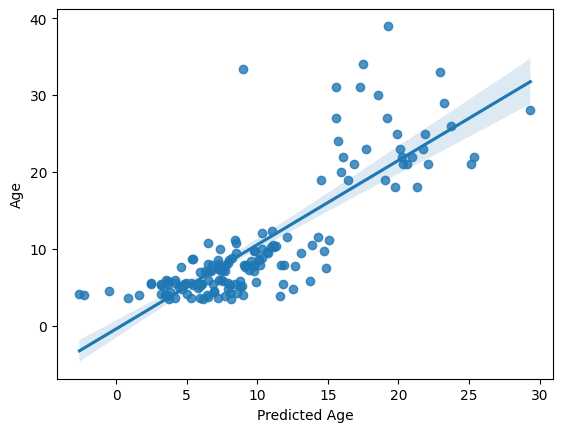

In [ ]:
loo =LeaveOneOut()
# or equivalently
# kf_loo = KFold(n_splits=len(y_train_valid))

loo_results = cross_validate(Pipeline(steps=[
                                        ("fisher_transformer", fisher_transformer),
                                        ("pca", PCA(n_components=0.95)),
                                        ("l_svr", SVR(kernel="linear")),
                                      ]),
                                X_features, y_age_arr,
                                cv=loo,
                                scoring="neg_mean_squared_error", # can't use R^2 because there's only one sample
                                return_train_score=True,
                                return_indices=True,
                                return_estimator=True)

#train_scores, test_scores = loo_results["train_score"], loo_results["test_score"]
estimators = loo_results["estimator"]
test_indices = loo_results["indices"]["test"]

ground_truths = np.concatenate([y_age_arr[test_idx] for test_idx in test_indices])
predictions = np.concatenate([est.predict(X_features[test_idx]) for est, test_idx in zip(estimators, test_indices)])
aggregated_r2 = r2_score(ground_truths, predictions)
print(f"LOOCV 'aggregated' R^2 = {aggregated_r2}")

sns.regplot(x=predictions, y=ground_truths)
plt.ylabel("Age")
plt.xlabel("Predicted Age")
plt.show()


### Binary SVM Classification with a linear kernel
> Please note that multi-class SVM classfication is implemented through [one-vs-rest](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html). The SVM algorithm is fundementally binary by design. So I'll start with binary as it's easier this way to get a better grasp of how SVM works.

In [15]:
y_group = pheno["AgeGroup"]
print(y_group.value_counts())

AgeGroup
8-12yo    34
5yo       34
Adult     33
7yo       23
3yo       17
4yo       14
Name: count, dtype: int64


In [21]:
# Divide the target into two classes: adult (1) vs children (-1), and insert a column "target"
# you don't NEED to numerically encode string labels AgeGroup for SVM to work, but I am doing downstream numpy array operations
# to check the support vector algebra, so I need numbers
target = np.where(pheno["AgeGroup"] == "Adult", 1, -1)
try:
    pheno.insert(list(pheno.columns).index("AgeGroup"), "target", target)
except ValueError:
    assert "target" in pheno.columns
#display(pheno.head())

In [22]:
TEST_SIZE = 0.15
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_features,
                                                                target, # <- passing pheno["AgeGroup"] will work too for the SVM model
                                                                        # but again, I will be doing matrix operations later, so I need to numerically encode them
                                                                test_size=TEST_SIZE,
                                                                shuffle=True,
                                                                stratify=target,  
                                                                random_state=RANDOM_STATE)
svm = SVC(kernel="linear", C=1.0, shrinking=False, tol=1e-5, max_iter=5000)  # C=1.0 is default; small dataset, no deed to shrink 
                                              
svm.fit(X_train_valid, y_train_valid)
print(f"Training accuracy {svm.score(X_train_valid, y_train_valid)}") # note that THIS IS ACCURACY!!!
print(f"Test accuracy {svm.score(X_test, y_test)}")

Training accuracy 1.0
Test accuracy 0.9583333333333334


Oh wow, binary classification performs REALLY well!! Let's look at the weights and <strong>support vectors</strong>, which are points that are either <strong>on the margin boundary</strong> or <strong>strictly within the margin</strong> (poitns on the margin are not necessarily support vectors though).

In [11]:
w, b = svm.coef_.ravel(), svm.intercept_
print(f"w.shape = {w.shape}; b.shape = {b.shape}")

multipliers = svm.dual_coef_
support_vecs, support_vec_indices = svm.support_vectors_, svm.support_
assert np.array_equal(support_vecs, X_train_valid[support_vec_indices])
w_from_dual = multipliers @ support_vecs # y is already absorded into svm.dual_coef (no idea why sklearn does this)
print(f"""\nWeights calculated from svm.dual_coef_ and svm.support_vectors_ directly minus svm.coef_:
    >> {np.max(abs(w - w_from_dual))}""")

y_hat = w @ X_train_valid.T + np.tile(b, X_train_valid.shape[0])
support_vec_indices_manual = np.where(y_train_valid * y_hat <= 1 + 1e-5)[0] # add a small numerical tolerance term 1e-5
print(f"""Support vector indices using the y[i] @ (w.T + b) <= 1 criterion is a subset of svm.support_:
    >> {set(support_vec_indices).issubset(set(support_vec_indices))}""")
print(f"Support vector indices =\n    {support_vec_indices}")
print(f"All non-zero multipliers <= C:\n    >> {np.all(multipliers <= svm.C)}")

w.shape = (2016,); b.shape = (1,)

Weights calculated from svm.dual_coef_ and svm.support_vectors_ directly minus svm.coef_:
    >> 0.0
Support vector indices using the y[i] @ (w.T + b) <= 1 criterion is a subset of svm.support_:
    >> True
Support vector indices =
    [  0   2   9  13  24  25  34  39  40  42  46  47  50  53  54  55  58  59
  62  63  65  71  78  79  81  82  83  89  90  91  96  98  99 105 106 110
 111 113 119 127   4   5   6  10  12  15  29  31  44  49  72  73  74  76
  77  85  86  92  97 114 115 120]
All non-zero multipliers <= C:
    >> True


Now I perform PCA to reduce the input dimenstion to 2, so the fitted decision boundary is essentially a line and it's easier to visualize (in higher dimnesional spaces, the decision boundary is a <strong>hyperplane</strong>). Note that this is for demonstration purposes only.

In [105]:
pca = PCA(n_components=2)
X_train_valid_pca = pca.fit_transform(X_train_valid)
print(f"Input matrix shape after PCA = {X_train_valid_pca.shape}")

svm.fit(X_train_valid_pca, y_train_valid)
print(f"\nTraining accuracy {svm.score(X_train_valid_pca, y_train_valid)}") # note that THIS IS ACCURACY!!!
X_test_pca = pca.transform(X_test)
print(f"Test accuracy {svm.score(X_test_pca, y_test)}")

w, b = svm.coef_.ravel(), svm.intercept_
print(f"\nw.shape = {w.shape}; b.shape = {b.shape}")

Input matrix shape after PCA = (131, 2)

Training accuracy 0.9007633587786259
Test accuracy 0.9583333333333334

w.shape = (2,); b.shape = (1,)


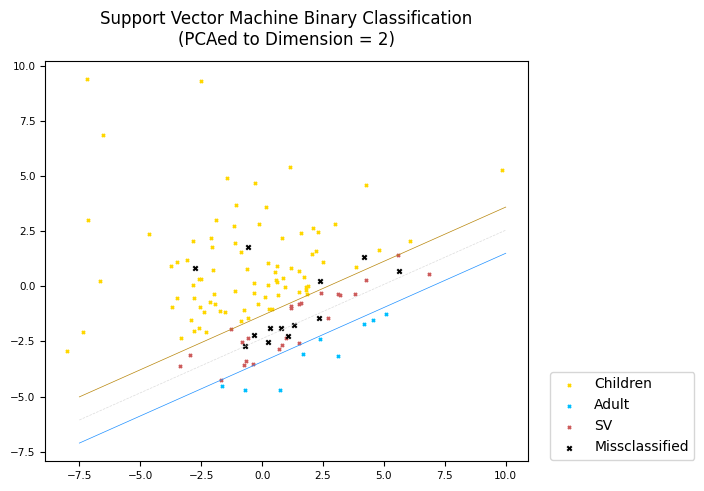

In [ ]:
colors, labels = ["gold", "deepskyblue", "indianred", "black"], [-1, 1, 0, 100]
label_map = {1: "Adult", -1: "Children", 0: "SV", 100: "Missclassified"}

y_to_plot = np.array([y if i not in svm.support_ else 0 for i, y in enumerate(y_train_valid)])
y_pred = svm.predict(X_train_valid_pca)
y_to_plot = np.array([i if j == k else 100 for i, j, k in zip(y_to_plot, y_pred, y_train_valid)])

plt.figure(figsize=(7.5, 4.5))
for color, label in zip(colors, labels):
    mask = y_to_plot == label
    plt.scatter(
        X_train_valid_pca[mask, 0],
        X_train_valid_pca[mask, 1],
        c=color,
        label=label_map[label],
        s=10 if label==100 else 4.5,
        marker="x" if label == 100 else "o"
    )
x = np.linspace(-7.5, 10, 100)
y = - w[0]/w[1] * x - b/w[1]
y1 = - w[0]/w[1] * x - b/w[1] - 1/w[1]
y2 = - w[0]/w[1] * x - b/w[1] + 1/w[1]
plt.plot(x, y, linewidth=0.5, linestyle="dashed", color="gainsboro")
plt.plot(x, y1, linewidth=0.5, color="darkgoldenrod")
plt.plot(x, y2, linewidth=0.5, color="dodgerblue")

plt.tick_params(axis="both", which="major", labelsize=7.5)
plt.legend(bbox_to_anchor=(1.36, 0.241))
plt.tight_layout()
plt.title("Support Vector Machine Binary Classification\n(PCAed to Dimension = 2)", y=1.02)
plt.show()

### Dealing with class imbalance
- Undersampling within each CV fold
- `CalibratedClassifierCV`